            **To Identify creditworthiness of potential borrowers**

LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals.

LoanTap deploys formal credit to salaried individuals and businesses 4 main financial instruments:

Personal Loan
EMI Free Loan
Personal Overdraft
Advance Salary Loan
This case study will focus on the underwriting process behind Personal Loan only

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1ZPYj7CZCfxntE8p2Lze_4QO4MyEOy6_d/view?usp=sharing" -O Loantap.csv


Downloading...
From: https://drive.google.com/uc?id=1ZPYj7CZCfxntE8p2Lze_4QO4MyEOy6_d
To: /content/Loantap.csv
100% 100M/100M [00:01<00:00, 63.6MB/s]


**Step 1:Exploratory Data Analysis**

In [ ]:
df = pd.read_csv("Loantap.csv")

NameError: name 'pd' is not defined

To understand Each datapoints and its corresponding Features from a individual loan application

In [ ]:
df.head(2).T

,0,1
loan_amnt,10000.0,8000.0
term,36 months,36 months
int_rate,11.44,11.99
installment,329.48,265.68
grade,B,B
sub_grade,B4,B5
emp_title,Marketing,Credit analyst
emp_length,10+ years,4 years
home_ownership,RENT,MORTGAGE
annual_inc,117000.0,65000.0


In [ ]:
balance = 36369.0
utilised = 0.418
total_credit = balance/utilised

In [ ]:
total_credit

87007.17703349283

In [ ]:
df.shape

(396030, 27)

In [ ]:
null = df.isna().sum()

In [ ]:
null_columns = null[null > 0]
print(null_columns)

emp_title               22927
emp_length              18301
title                    1756
revol_util                276
mort_acc                37795
pub_rec_bankruptcies      535
dtype: int64


- These Columns has null values,which needs to be treated based on the importance of data.

emp_title               22927
emp_length              18301
title                    1756
revol_util                276
mort_acc                37795
pub_rec_bankruptcies      535-

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,396030.0,14113.888089,8357.441341,500.00,8000.00,12000.00,20000.00,40000.00
int_rate,396030.0,13.639400,4.472157,5.32,10.49,13.33,16.49,30.99
installment,396030.0,431.849698,250.727790,16.08,250.33,375.43,567.30,1533.81
annual_inc,396030.0,74203.175798,61637.621158,0.00,45000.00,64000.00,90000.00,8706582.00
dti,396030.0,17.379514,18.019092,0.00,11.28,16.91,22.98,9999.00
open_acc,396030.0,11.311153,5.137649,0.00,8.00,10.00,14.00,90.00
pub_rec,396030.0,0.178191,0.530671,0.00,0.00,0.00,0.00,86.00
revol_bal,396030.0,15844.539853,20591.836109,0.00,6025.00,11181.00,19620.00,1743266.00
revol_util,395754.0,53.791749,24.452193,0.00,35.80,54.80,72.90,892.30
total_acc,396030.0,25.414744,11.886991,2.00,17.00,24.00,32.00,151.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

Segregating Catagorical and Numerical columns

In [ ]:
obj_columns = df.select_dtypes(include='object')
int_columns = df.select_dtypes(include ='float64')

In [ ]:
int_columns.columns

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies', 'emp_length_yrs'],
      dtype='object')

In [ ]:
obj_columns.columns

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'loan_status', 'purpose',
       'title', 'initial_list_status', 'application_type', 'address', 'city',
       'state'],
      dtype='object')

In [ ]:
loan_counts = df['loan_status'].value_counts()

In [ ]:
df["loan_status_num"] = df["loan_status"].map({'Fully Paid':1,'Charged Off':0})

In [ ]:
df.value_counts("loan_status_num"),df["loan_status"].value_counts()

(loan_status_num
 1    318357
 0     77673
 Name: count, dtype: int64,
 loan_status
 Fully Paid     318357
 Charged Off     77673
 Name: count, dtype: int64)

In [ ]:
df.dtypes

,0
loan_amnt,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_title,object
emp_length,object
home_ownership,object
annual_inc,float64


In [ ]:
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,18301
home_ownership,0
annual_inc,0


In [ ]:
int_columns.columns.value_counts().sum()

np.int64(12)

In [ ]:
def plot_distribution_and_box(ax, data, feature):
    # Distribution Plot (KDE)
    sns.kdeplot(data[feature].round(2), ax=ax[0], color='blue', fill=True, alpha=0.5, linewidth=2)
    ax[0].set_title(f'Distribution of {feature}', fontsize=16)
    ax[0].set_xlabel(feature, fontsize=14)
    ax[0].set_ylabel('Density', fontsize=14)

    # Box Plot
    sns.boxplot(x=data[feature], ax=ax[1], color='lightgray')
    ax[1].set_title(f'Box Plot of {feature}', fontsize=16)
    ax[1].set_xlabel(feature, fontsize=14)

In [ ]:
df["pub_rec_bankruptcies"].value_counts()

,count
pub_rec_bankruptcies,
0.0,350380
1.0,42790
2.0,1847
3.0,351
4.0,82
5.0,32
6.0,7
7.0,4
8.0,2


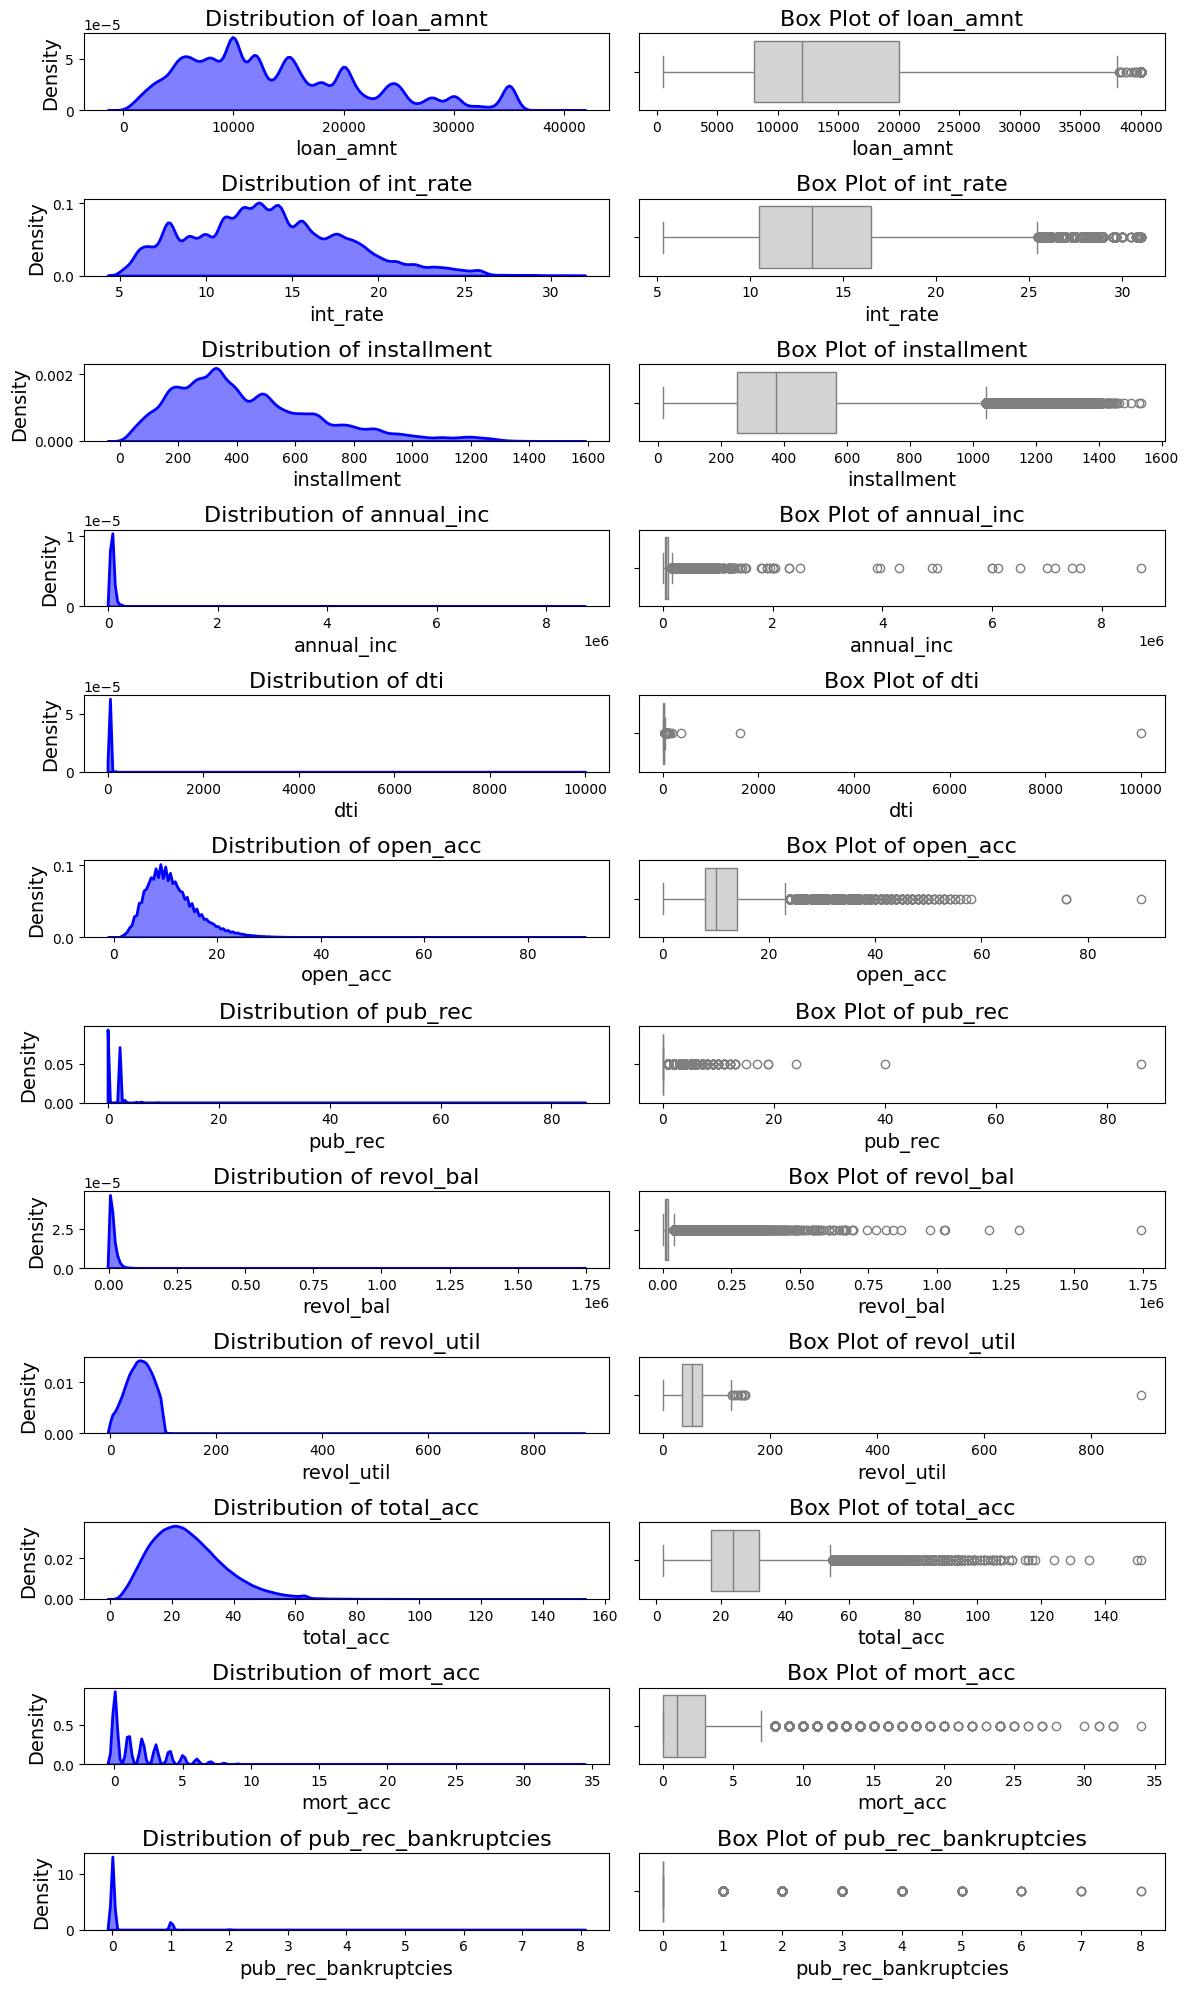

In [ ]:
fig, axs = plt.subplots(12, 2, figsize=(12, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
j = 0  # Row index counter
for i in int_columns.columns:
  plot_distribution_and_box(axs[j], df, i)
  j = j+1
plt.tight_layout()
plt.show()

**1. Distribution of loan_amnt (Amount borrower applied for)**

- Majority of the applicants loans are cluster between 10000 ,20000 and 3500 which is seen clearly though the peaks in these loan amount of the density plot.
There are also some outliers with loan amount greater than 45000

**2.Distribution of interest Rates **
- Tnterest rate are the key risk indicators.Interest rates of majority  of the loans lies between 10% to 16% which shows Loan tap lendered theirs loan to low risk customers.Its is also clear from the box plot that loan tap issued loans to high risk customers whose intereast rates are between 25% to 30%.

**3.Distribution of installments**
- The density plot for installment is heavily right-skewed, meaning most monthly repayment amounts are relatively low (below 400). The installment is the required monthly repayment amount.

- The box plot clearly indicates a large number of data points classified as outliers in the high installment range (e.g., above $1,000). These high installments represent large financial burdens, which are directly related to the high loan_amnt and/or high int_rate

**4.Distribution of Annual income**
- Most borrowers have relatively low annual income, concentrated very close to zero compared with the maximum values in the dataset.​

- A long right tail indicates a small number of borrowers with very high reported incomes, stretching the distribution and making it non‑normal
-The box and whiskers are compressed near the lower end, while many individual points lie far to the right, which are outliers

5.Distribution of DTI(debt to income ratio)

- On average borrowers use about 17% of income to service debt, with a fairly large spread around this average
- There is also Debt to income ratio which 9999 ,which might be error in the data or invalid data

5.Distribution of DTI(debt to income ratio)

- No of open loan accounts are between 0 to 20 for majority of the customers.

- As per box plot ,max of no of loan account open for customer is 80 whihc se
ems to be invalid data and need to further analysis on this.

6.Distribubution of neg public records
Majority of the loan applicants of LoanTap has no negative public records,Which indicates the less risk of loans getting defaulted.

Also Box plot indicats that some applicants are having high negative records and their loans needs to be investigated.

Loans applicants utilized their credit line between 35% to 75 % approximately.
7.Distribution of total_acc
On Average borrower's  has 20 other loan credit accounts which is evedent from
total_acc distribution
Box plot clearly indicates that there are some borrower's having credit account more than 40.Those are high risk customers which needs to carefuly considered before proceeding their next loan applications

**7.Distribution of mortgage accounts**

The mort_acc distribution is heavily concentrated near 0–3, with density quickly dropping as values increase, meaning most borrowers have very few mortgage accounts.​

The box plot shows a long line of points to the right, indicating many high-value outliers; however, the median is low and the IQR is narrow, so typical customers still have low mort_acc

Distribution of pub_rec_bankruptcies

The pub_rec_bankruptcies distribution is almost entirely at 0, with a small mass at 1 and very rare values above 1, suggesting bankruptcies are uncommon in this dataset.​

The corresponding box plot again has a cluster at 0 and scattered high outliers, which means a binary treatment (0 vs ≥1) might be more informative than treating this strictly as a continuous variable
















In [ ]:
sns.set_theme(style = 'dark')
def feature_countplot(ax, data, feature, title='Count Plot', xlabel=None, ylabel='Count', palette='viridis'):
    sns.countplot(data=data, x=feature, palette=palette, ax=ax)

    # Adding title and labels
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel if xlabel else feature, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # Customizing ticks
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Adding value annotations on top of the bars
    for p in ax.patches:
      ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)

In [ ]:
obj_columns.columns

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

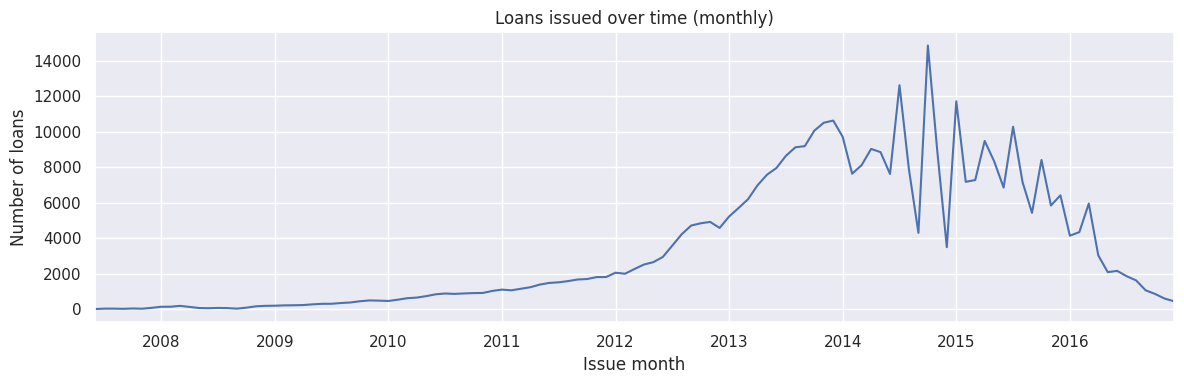

In [ ]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_per_month']= df['issue_d'].dt.to_period('M')
issue_per_month = df['issue_per_month'].value_counts().sort_index()
plt.figure(figsize=(12,4))
issue_per_month.plot(kind='line')
plt.xlabel('Issue month')
plt.ylabel('Number of loans')
plt.title('Loans issued over time (monthly)')
plt.tight_layout()
plt.show()



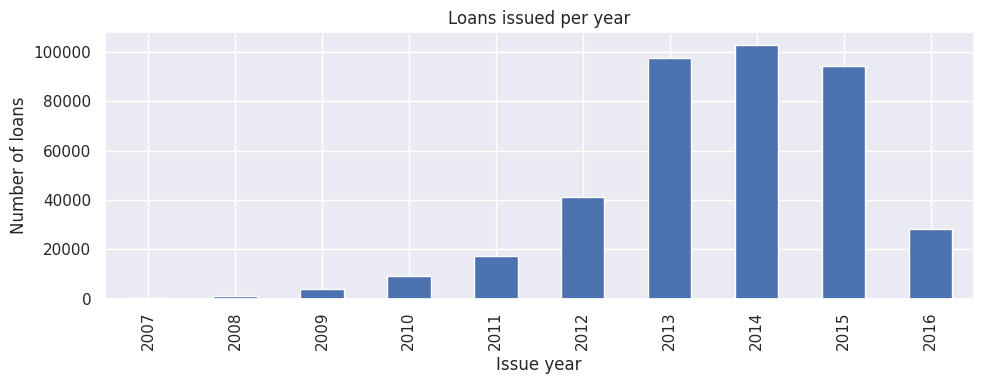

In [ ]:
df['issue_year']= df['issue_d'].dt.year
issue_year = df['issue_year'].value_counts().sort_index()
plt.figure(figsize=(10,4))
issue_year.plot(kind='bar')
plt.xlabel('Issue year')
plt.ylabel('Number of loans')
plt.title('Loans issued per year')
plt.tight_layout()
plt.show()

- “Loan issuance volume increased sharply from 2011 and peaked in 2013–2014, indicating a period of rapid portfolio growth.”

- “Post‑2014, the annual number of loans declined, so later years have fewer observations, which the model should account for when interpreting time‑based patterns.”

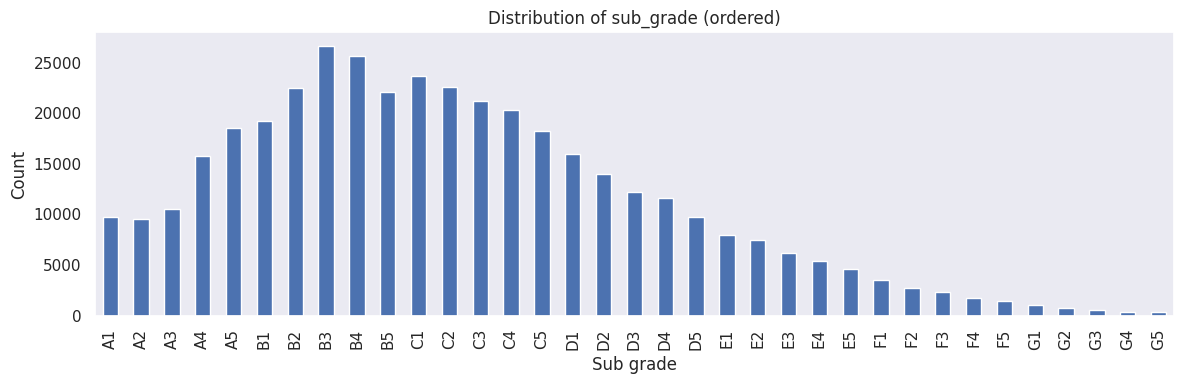

In [ ]:
order = sorted(df['sub_grade'].unique(),
               key=lambda x: (x[0], int(x[1])))  # letter, then number

sub_grade_counts = df['sub_grade'].value_counts().reindex(order)

plt.figure(figsize=(12,4))
sub_grade_counts.plot(kind='bar')
plt.xlabel('Sub grade')
plt.ylabel('Count')
plt.title('Distribution of sub_grade (ordered)')
plt.tight_layout()
plt.show()

- The portfolio is concentrated in mid‑risk sub‑grades B and C, while high‑risk F and G segments are relatively small, so the model will see more examples from better‑quality borrowers.
- Because lower‑quality grades have fewer observations, their default behaviour may be harder to estimate accurately; this should be considered during modelling and evaluation.
-

/tmp/ipython-input-529419599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette=palette, ax=ax)
/tmp/ipython-input-529419599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette=palette, ax=ax)
/tmp/ipython-input-529419599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette=palette, ax=ax)
/tmp/ipython-input-529419599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

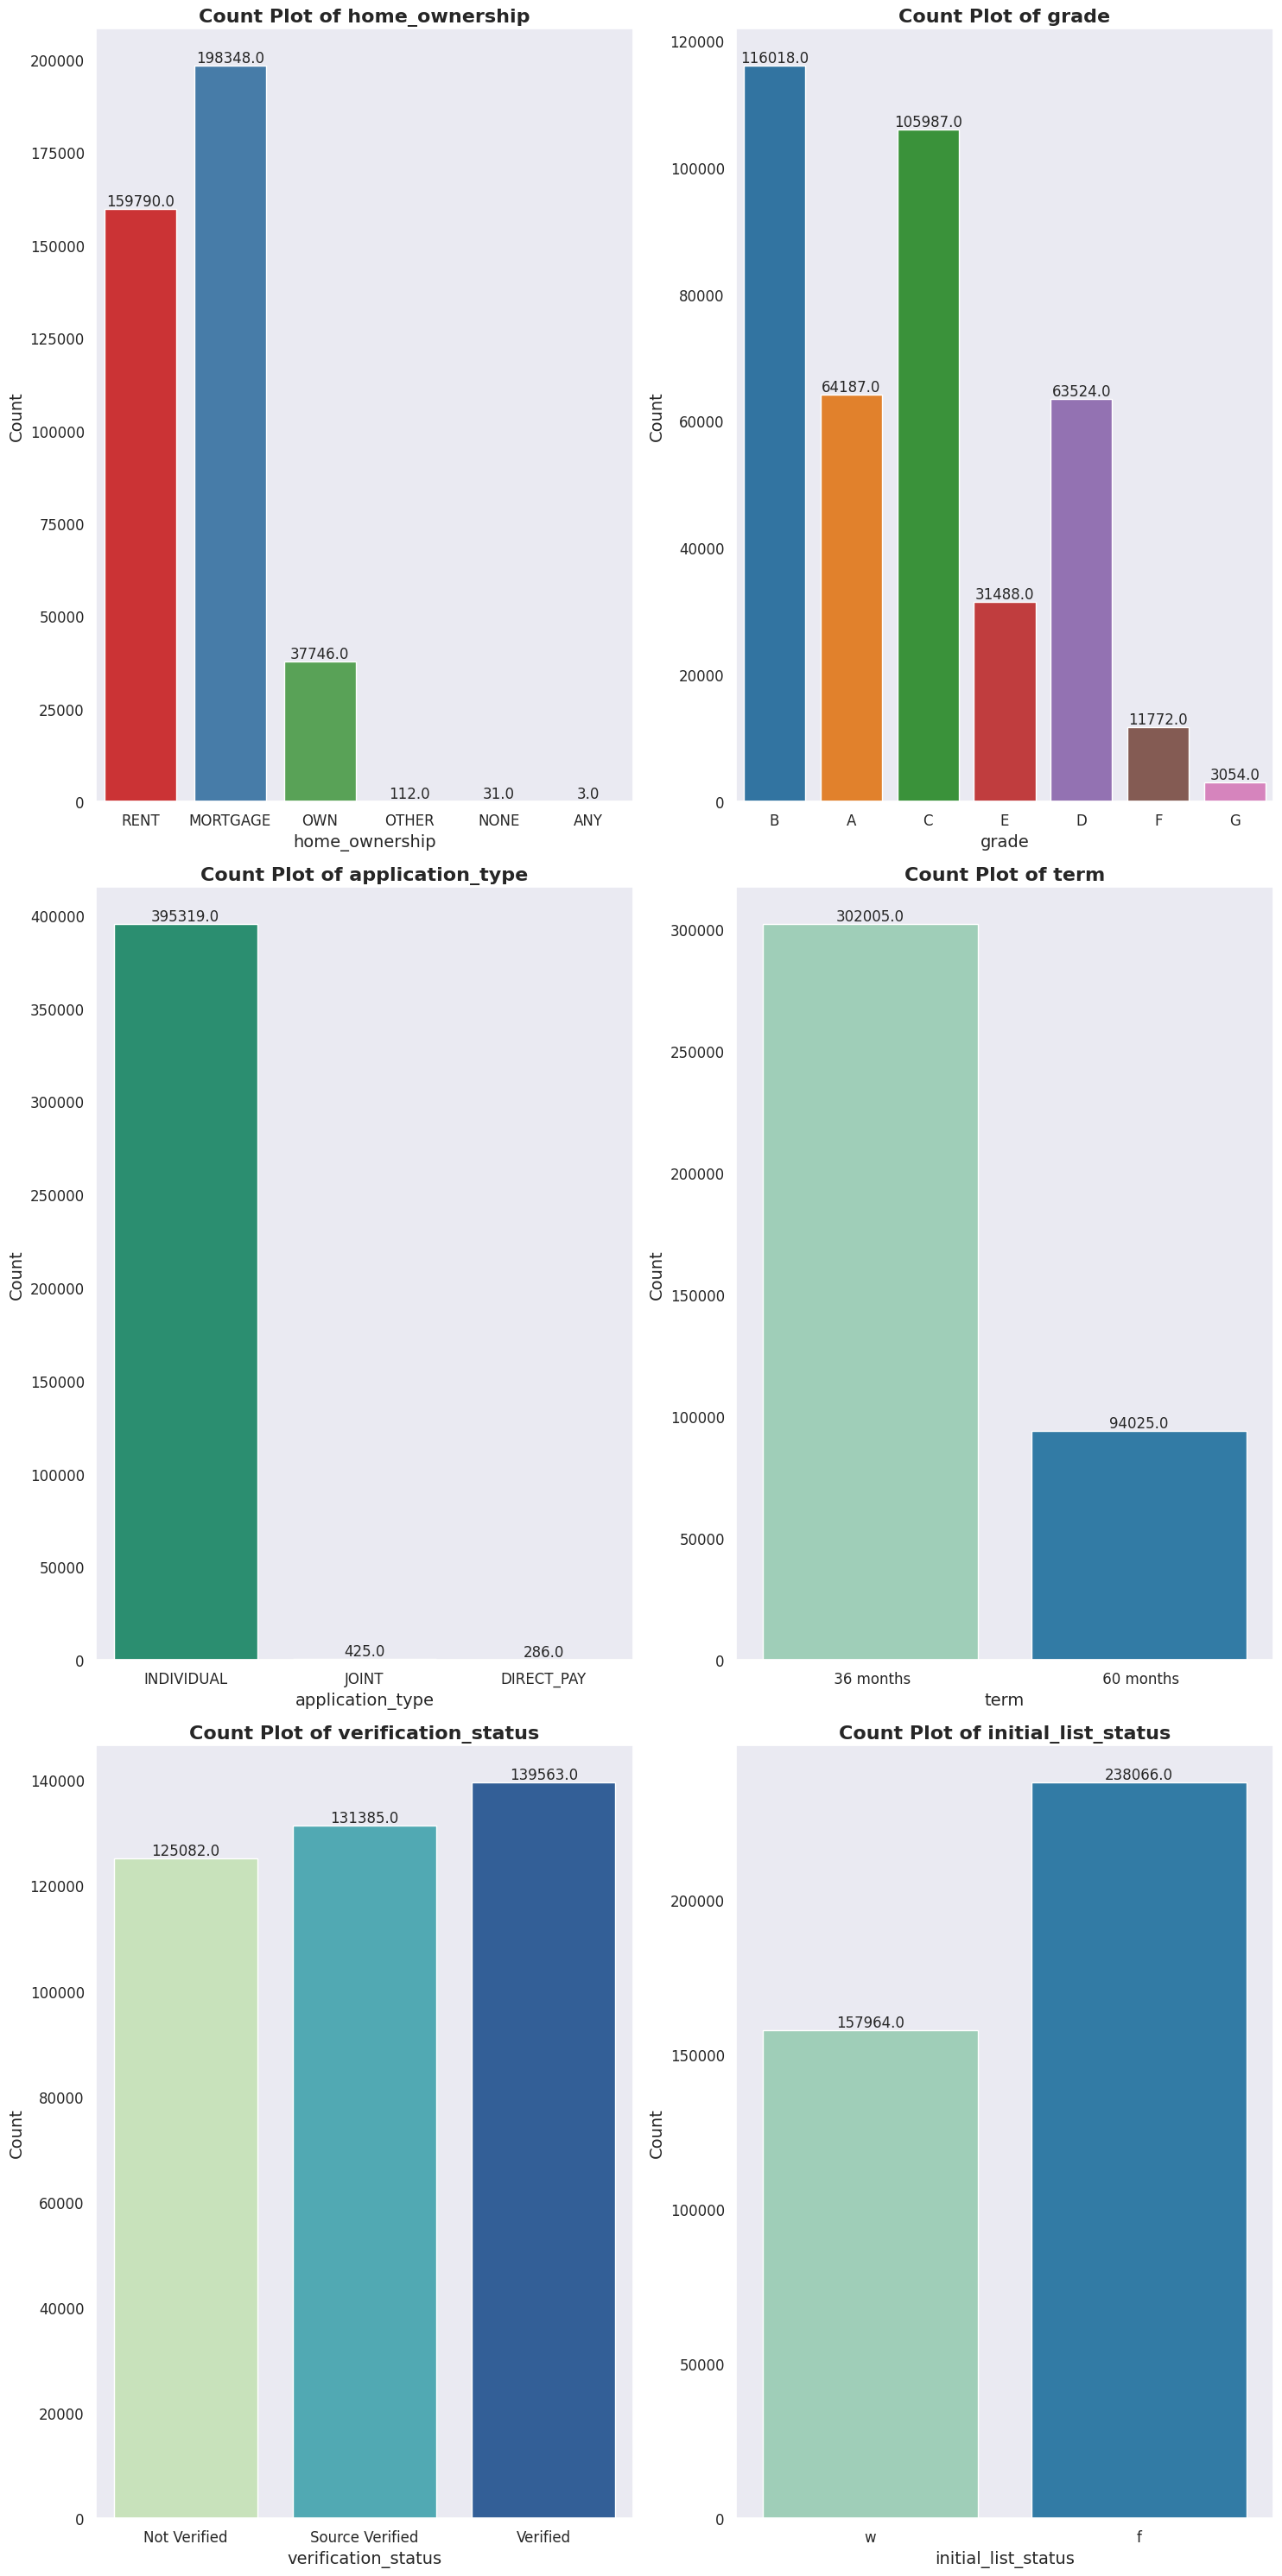

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(15, 30))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

feature_countplot(axs[0, 0], data=df, feature='home_ownership', title='Count Plot of home_ownership', ylabel='Count', palette='Set1')
feature_countplot(axs[0, 1], data=df, feature='grade', title='Count Plot of grade', xlabel='grade', ylabel='Count', palette='tab10')
feature_countplot(axs[1, 0], data=df, feature='application_type', title='Count Plot of application_type', xlabel='application_type', ylabel='Count', palette='Dark2')
feature_countplot(axs[1, 1], data=df, feature='term', title='Count Plot of term', xlabel='term', ylabel='Count', palette='YlGnBu')
feature_countplot(axs[2, 0], data=df, feature='verification_status', title='Count Plot of verification_status', xlabel='verification_status', ylabel='Count', palette='YlGnBu')
feature_countplot(axs[2,1], data=df, feature='initial_list_status', title='Count Plot of initial_list_status', xlabel='initial_list_status', ylabel='Count', palette='YlGnBu')


plt.tight_layout()
plt.show()

- **home_ownership:** Most borrowers either mortgage their homes or rent, with a much smaller share who own outright; categories like OTHER/NONE/ANY are negligible, so they could be grouped if needed to reduce sparsity.

- **grade**: Portfolios are concentrated in grades B, A, C, and D, while very risky grades F and especially G have far fewer loans, meaning the model will see many more medium‑risk than high‑risk examples.

- **application_type**: Almost all applications are INDIVIDUAL, with very few JOINT or DIRECT_PAY loans, so those minority categories may need careful handling or grouping when modelling.

-**term**: About three‑quarters of loans have a 36‑month term and the rest 60‑month, showing a clear preference for shorter tenures.

- **verification_status**: Counts for Verified, Source Verified, and Not Verified are fairly similar, so verification practices are mixed and could have a meaningful relationship with risk.

- **initial_list_status (W/F)**: More loans start as F (fractional) than W (whole), indicating that a larger share is offered to many small investors rather than as whole loans

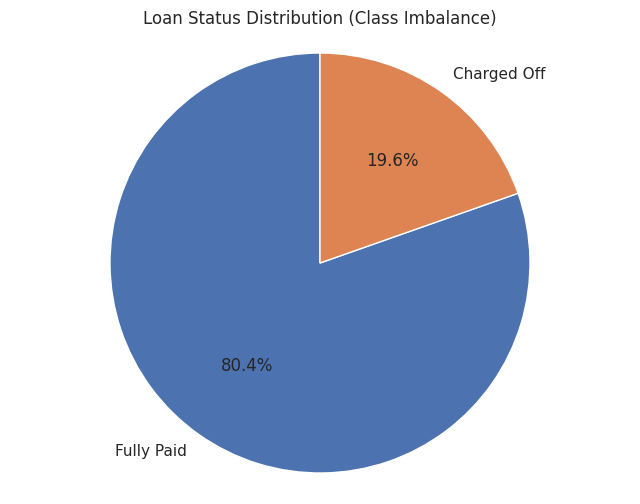

In [ ]:
plt.figure(figsize=(8, 6))
plt.pie(loan_counts.values,
        labels=loan_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Loan Status Distribution (Class Imbalance)')
plt.axis('equal')
plt.show()

- This clearly shows that the data is not balanced since fully paid loan details constitute 80% of the applicants data whereas the defaulted loan applicant constitute 20% of overall dataset.

- This imbalance in data between fully paid loans and defaulted loans need to be fixed to improve the accuracy of the model

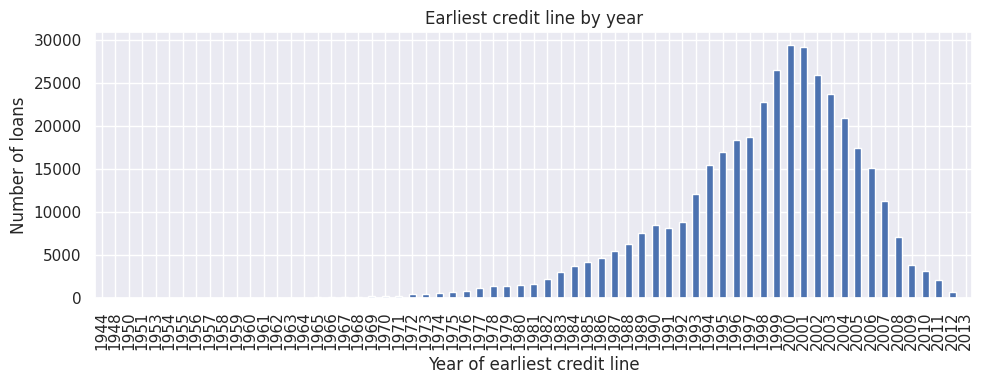

In [ ]:
df['earliest_cr_line'] = pd.to_datetime(
    df['earliest_cr_line'],
    format='%b-%Y',
    errors='coerce'      # invalid parses become NaT
)
df['cr_by_year'] =df['earliest_cr_line'].dt.year
df['cr_by_month'] =df['earliest_cr_line'].dt.to_period('M')
cr_by_year = df['cr_by_year'].value_counts().sort_index()
cr_by_month = df['cr_by_month'].value_counts().sort_index()
plt.figure(figsize=(10,4))
cr_by_year.plot(kind='bar')
plt.xlabel('Year of earliest credit line')
plt.ylabel('Number of loans')
plt.title('Earliest credit line by year')
plt.tight_layout()
plt.show()


Most Borrower's opened their credit line starting from year 1990 and early 2000's which are clear indication that they have good line of credit history which healps to access to customer behaviour in depth

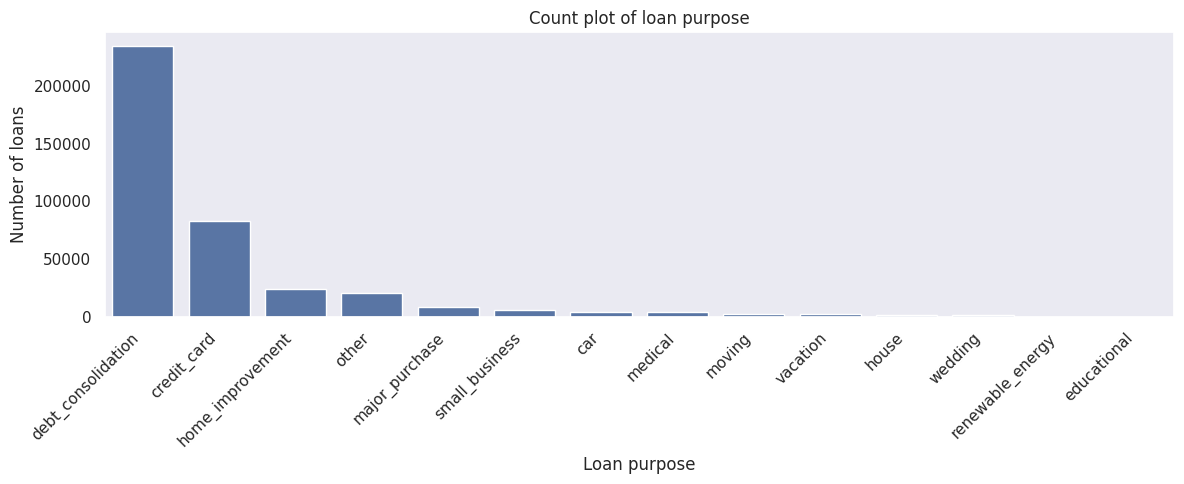

In [ ]:
plt.figure(figsize=(12,5))

# order purposes by frequency (optional but useful)
order = df['purpose'].value_counts().index

sns.countplot(data=df, x='purpose', order=order)
plt.xlabel('Loan purpose')
plt.ylabel('Number of loans')
plt.title('Count plot of loan purpose')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Most of the borrwer's are taking loan for the purpose of consolidation of  their debts follwoed by credit card repayments and home improvement,rest all purpose consititue very tiny fraction

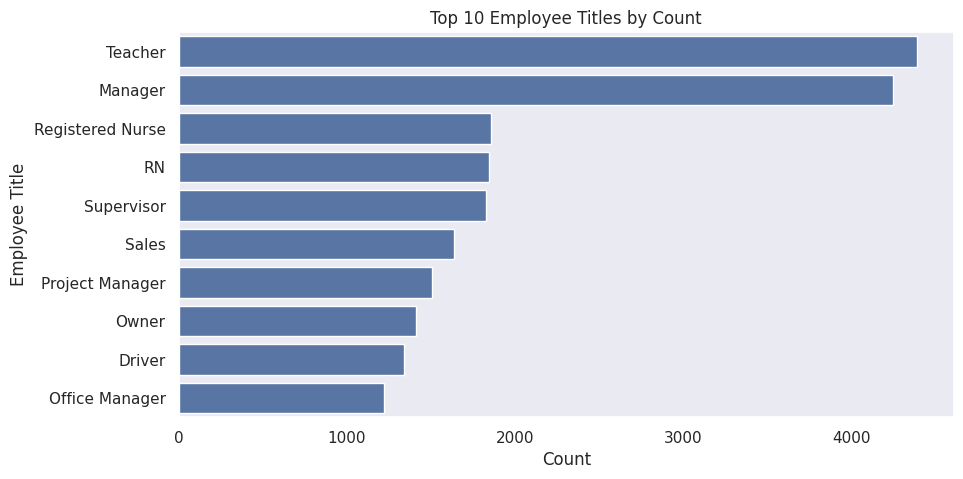

In [ ]:
top_titles = df['emp_title'].value_counts().head(10).index
df_top = df[df['emp_title'].isin(top_titles)]

plt.figure(figsize=(10, 5))
sns.countplot(data=df_top, y='emp_title', order=top_titles)
plt.title("Top 10 Employee Titles by Count")
plt.xlabel("Count")
plt.ylabel("Employee Title")
plt.show()

In [ ]:
# example values: '< 1 year','1 year','2 years',...,'10+ years','n/a'
mapping = {
    '10+ years': 10,
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    'n/a': np.nan   # or 0, depending on how you want to treat it
}

df['emp_length_yrs'] = df['emp_length'].replace(mapping).astype('float')

/tmp/ipython-input-3145071851.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['emp_length_yrs'] = df['emp_length'].replace(mapping).astype('float')


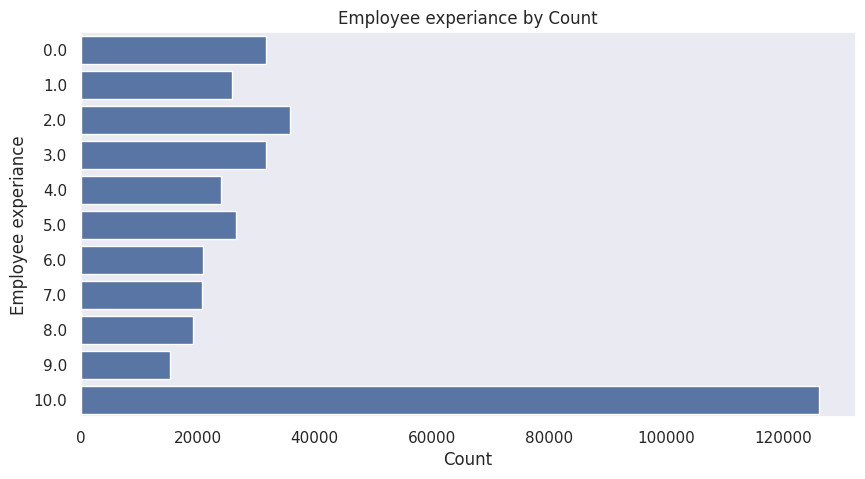

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='emp_length_yrs')
plt.title("Employee experiance by Count")
plt.xlabel("Count")
plt.ylabel("Employee experiance")
plt.show()

- A large share of applicants have 10+ years of employment, while the rest are spread fairly evenly across 0–9 years, suggesting the portfolio is skewed towards experienced employees

- The most common category is 10 years of experience ), which has by far the highest count; many borrowers report long, stable employment histories

In [ ]:
pattern = r'\r\n(.+),\s*([A-Z]{2})\s*\d{5}$'

df[['city', 'state']] = df['address'].str.extract(pattern)

# Quick check
df[['address', 'city', 'state']].head()

,address,city,state
0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690",Mendozaberg,OK
1,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113",Loganmouth,SD
2,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113",New Sabrina,WV
3,"823 Reid Ford\r\nDelacruzside, MA 00813",Delacruzside,MA
4,"679 Luna Roads\r\nGreggshire, VA 11650",Greggshire,VA


In [ ]:
pat1 = r'\r?\n(.+),\s*([A-Z]{2})\s*\d{5}$'
tmp1 = df['address'].str.extract(pat1)
tmp1.columns = ['city1', 'state1']
# Pattern 2: FPO/DPO/APO ST ZIP
pat2 = r'\r?\n(?:APO|FPO|DPO)\s+([A-Z]{2})\s*\d{5}$'
# use FPO/DPO/APO as city label; state from group 1
city2 = df['address'].str.extract(r'\r?\n(APO|FPO|DPO)\s+[A-Z]{2}\s*\d{5}$')[0]
state2 = df['address'].str.extract(pat2)[0]
df['city'] = tmp1['city1'].fillna(city2)
df['state'] = tmp1['state1'].fillna(state2)

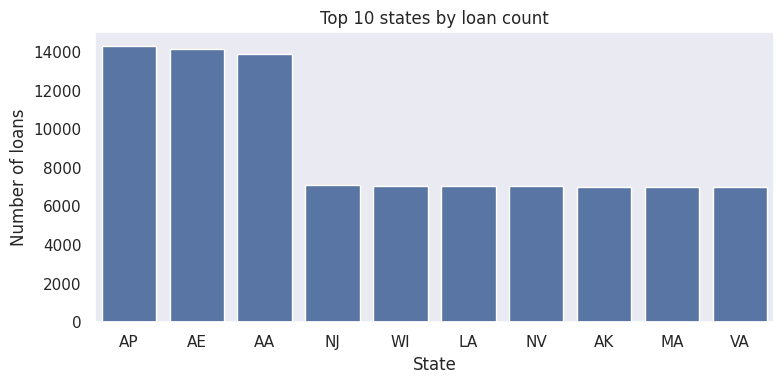

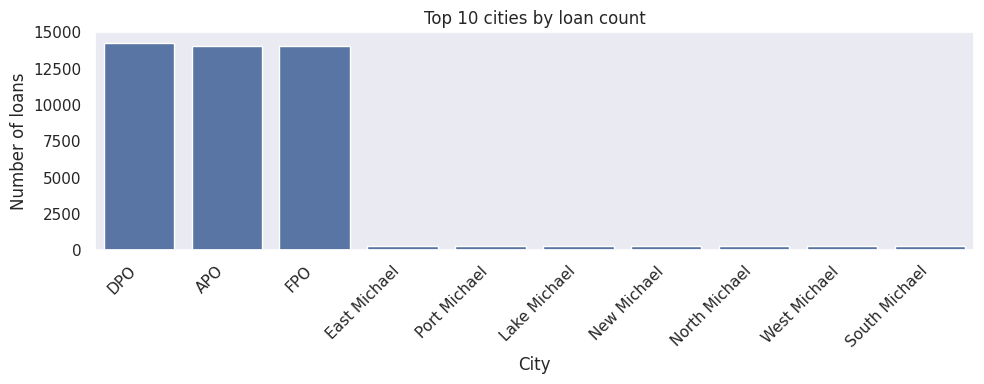

In [ ]:
state_counts = df['state'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.xlabel('State')
plt.ylabel('Number of loans')
plt.title('Top 10 states by loan count')
plt.tight_layout()
plt.show()

city_counts = df['city'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=city_counts.index, y=city_counts.values)
plt.xlabel('City')
plt.ylabel('Number of loans')
plt.title('Top 10 cities by loan count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- States like AP,AE,AR has close to 14000 borrowers wheras other states like NJ,WI,LA,NV,AK,MA,VA are having close to 7000 borrowers.
-Concentrating more in these 3 states canhep to gorw more customer base and to increase the revenue.
- DPO,APO and FPO has highest number of borrower close to 13000 compared to other cities which constitute very less in numbers

**Bivariate analysis**

In [ ]:
sns.set_theme()
def correlation_plot(data, x_feature, y_feature, title='Scatter Plot', xlabel=None, ylabel=None):
    plt.figure(figsize=(9, 6))

    sns.scatterplot(data=data, x=x_feature, y=y_feature, alpha=0.7, color='blue')

    # Adding title and labels
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel if xlabel else x_feature, fontsize=14)
    plt.ylabel(ylabel if ylabel else y_feature, fontsize=14)

    plt.tight_layout()
    plt.show()

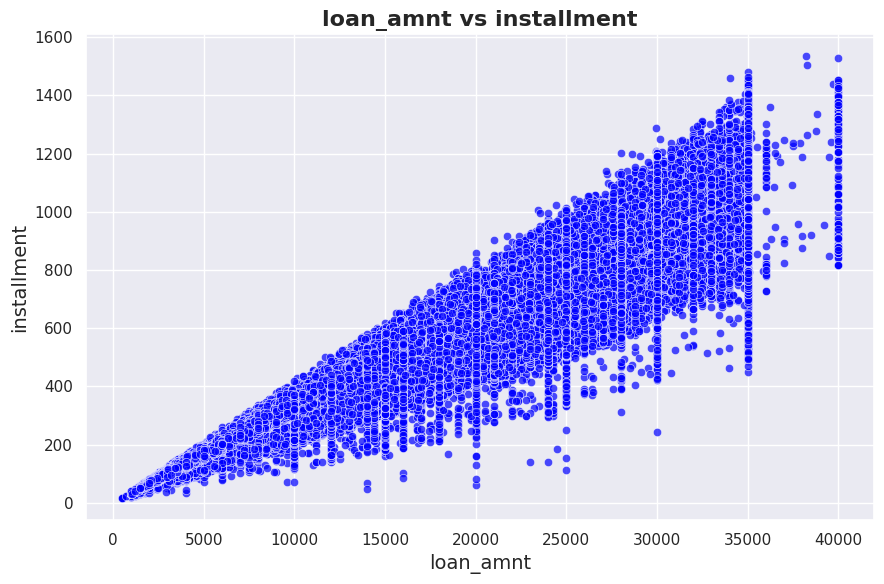

In [ ]:
correlation_plot(df, 'loan_amnt', 'installment', title='loan_amnt vs installment')

- Loan amount and Installment have a positive corelation, peeple with higher loan amount has higher installment to be paid.

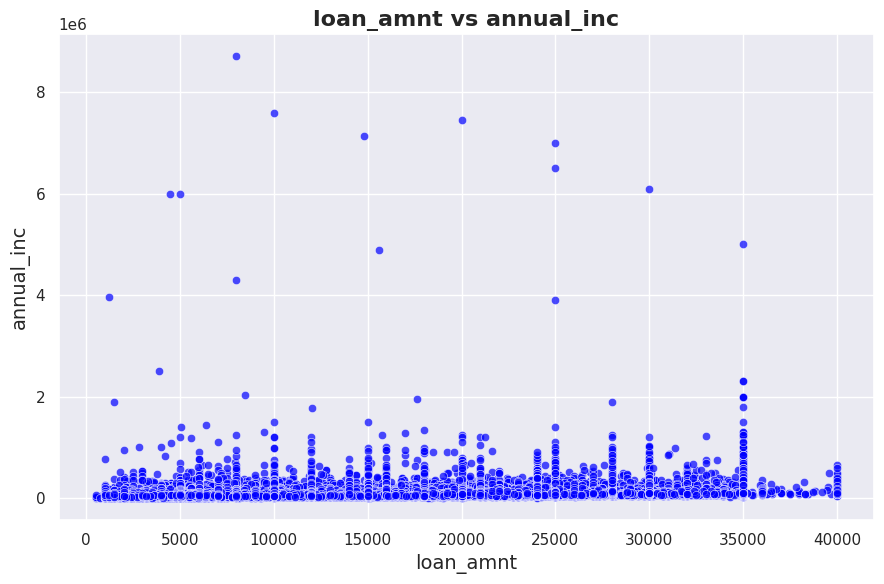

In [ ]:
correlation_plot(df, 'loan_amnt', 'annual_inc', title='loan_amnt vs annual_inc')

_ Most loans are taken by the borrowers whose annual income is less that 2 lakshs

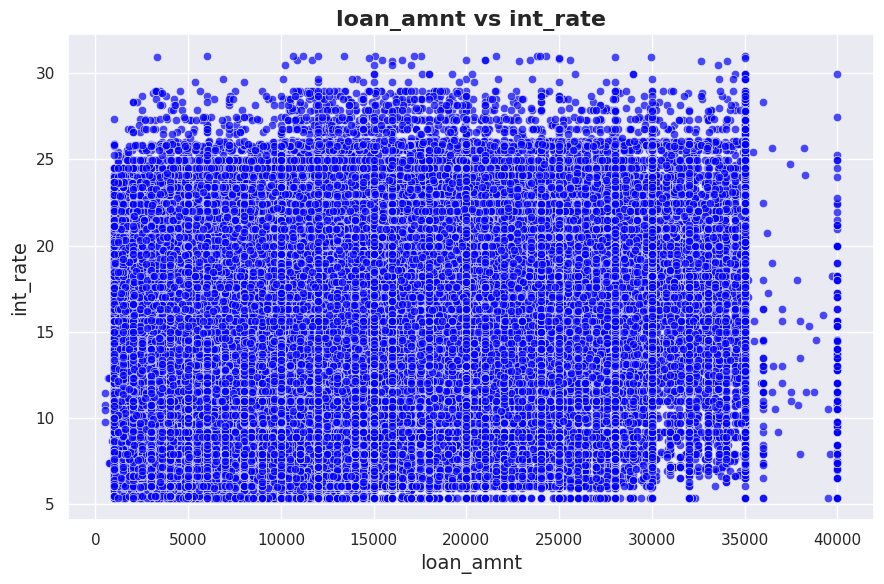

In [ ]:
correlation_plot(df, 'loan_amnt', 'int_rate', title='loan_amnt vs int_rate')

- For almost every loan amount range, interest rates span most of the vertical range (roughly 5–30%), so larger loans do not clearly get consistently higher or lower rates in this dataset

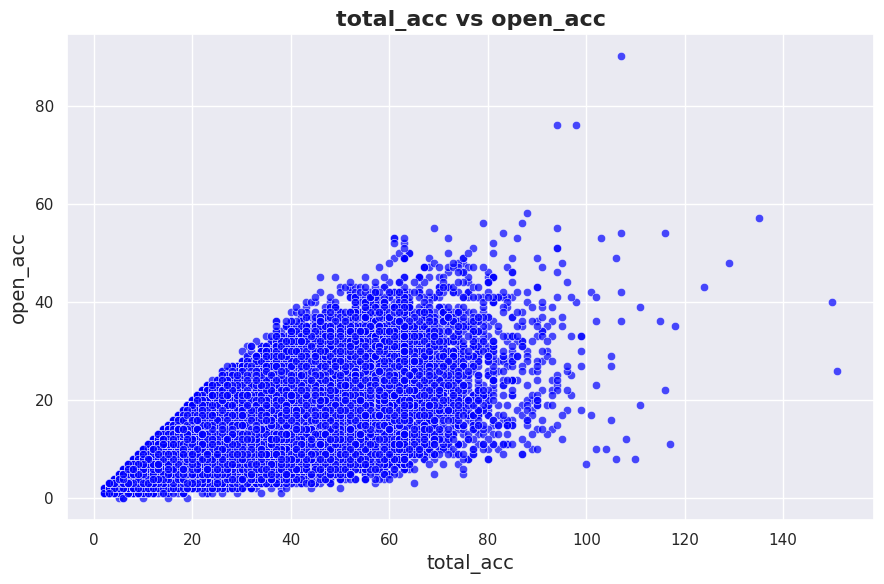

In [ ]:
correlation_plot(df, 'total_acc', 'open_acc', title='total_acc vs open_acc')

- open_acc and total_acc are moderately positively related, but not perfectly collinear; customers with many total accounts tend to keep more open lines, though the proportion of open accounts decreases as their total credit history length and complexity grow

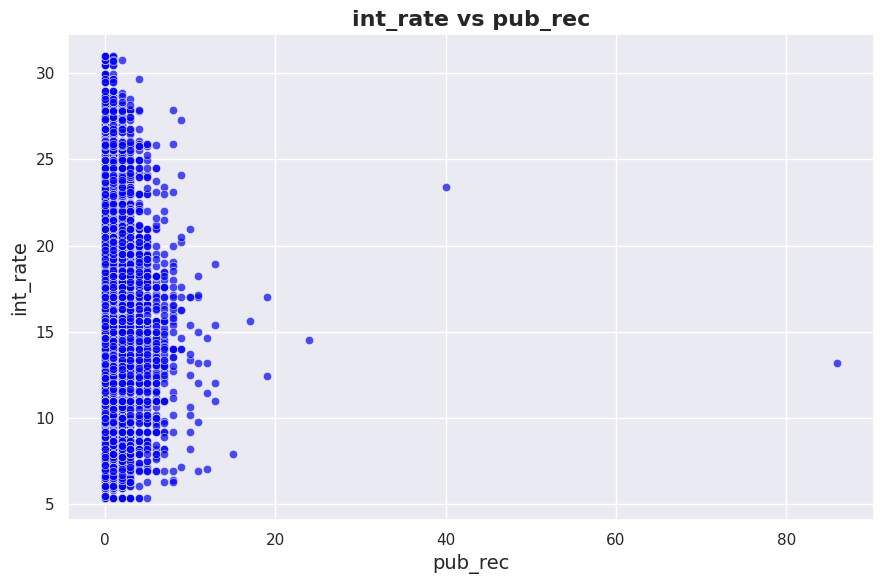

In [ ]:
correlation_plot(df, 'pub_rec', 'int_rate', title='int_rate vs pub_rec')

The scatter plot shows almost no meaningful relationship between pub_rec (public derogatory records) and int_rate (interest rate).​

Most borrowers have very low pub_rec values (0–5), yet their interest rates vary widely across the full range, which suggests other features are driving pricing more strongly than pub_rec.​

A few extreme outliers with unusually high pub_rec (around 40 and 85) appear, but their interest rates are not correspondingly extreme, so these should be treated as potential anomalies or very rare cases during modeling

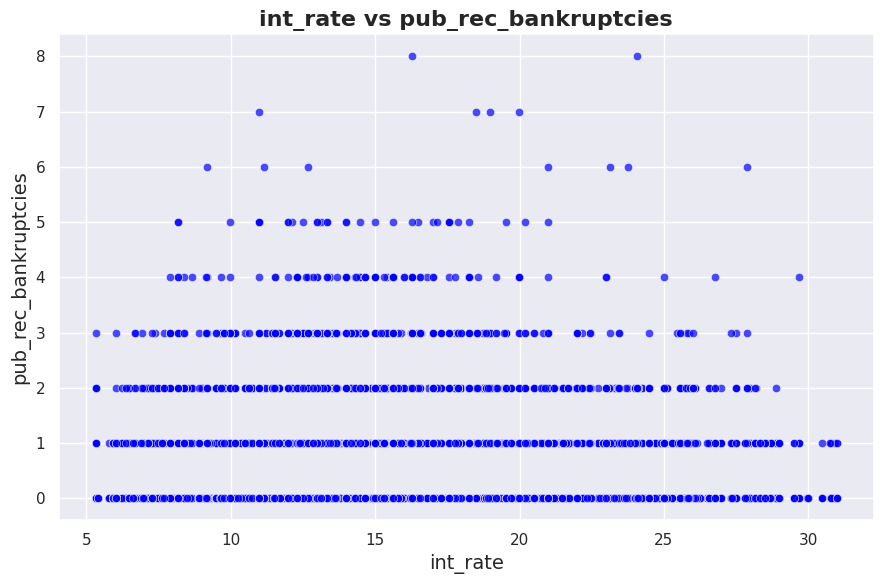

In [ ]:
correlation_plot(df, 'int_rate', 'pub_rec_bankruptcies', title='int_rate vs pub_rec_bankruptcies')

From this plot also there is no clear linear relationship between int_rate and pub_rec_bankruptcies. Interest rates are spread across the full range for each bankruptcy count (0–8), which suggests that the number of public bankruptcies alone is not a strong driver of pricing.​

Most customers have 0–3 bankruptcies, and even among those with higher counts the interest rates do not consistently shoot up, so this variable may have limited standalone predictive power and might work better in combination with other credit-risk features


Crosstab: term vs loan_status


loan_status,Charged Off,Fully Paid
term,,
36 months,0.157746,0.842254
60 months,0.319415,0.680585


<Figure size 1000x600 with 0 Axes>

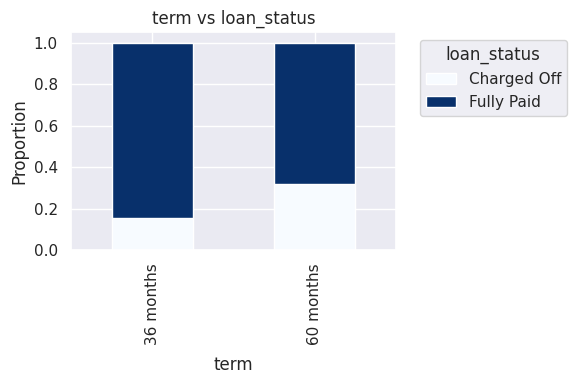


Crosstab: grade vs loan_status


loan_status,Charged Off,Fully Paid
grade,,
A,0.062879,0.937121
B,0.125730,0.874270
C,0.211809,0.788191
D,0.288678,0.711322
E,0.373634,0.626366
F,0.427880,0.572120
G,0.478389,0.521611


<Figure size 1000x600 with 0 Axes>

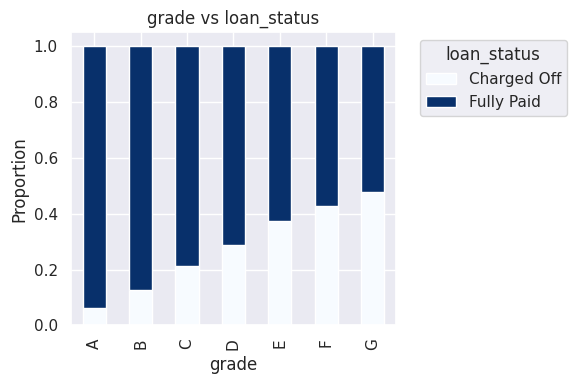


Crosstab: sub_grade vs loan_status


loan_status,Charged Off,Fully Paid
sub_grade,,
A5,0.084908,0.915092
B1,0.098582,0.901418
B2,0.108513,0.891487
B3,0.123354,0.876646
B4,0.138393,0.861607
B5,0.155037,0.844963
C1,0.173696,0.826304
C2,0.197520,0.802480
C3,0.218416,0.781584


<Figure size 1000x600 with 0 Axes>

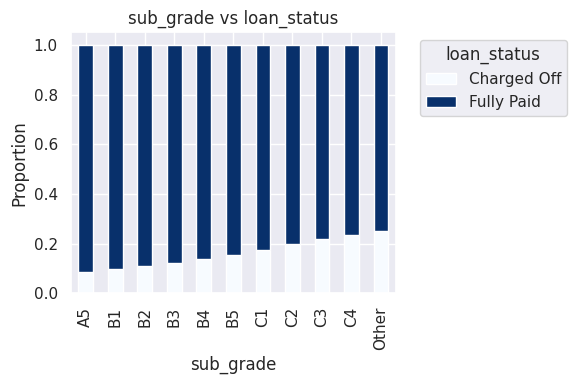


Crosstab: emp_length vs loan_status


loan_status,Charged Off,Fully Paid
emp_length,,
1 year,0.199135,0.800865
10+ years,0.184186,0.815814
2 years,0.193262,0.806738
3 years,0.195231,0.804769
4 years,0.192385,0.807615
5 years,0.192187,0.807813
6 years,0.189194,0.810806
7 years,0.194774,0.805226
8 years,0.199760,0.800240


<Figure size 1000x600 with 0 Axes>

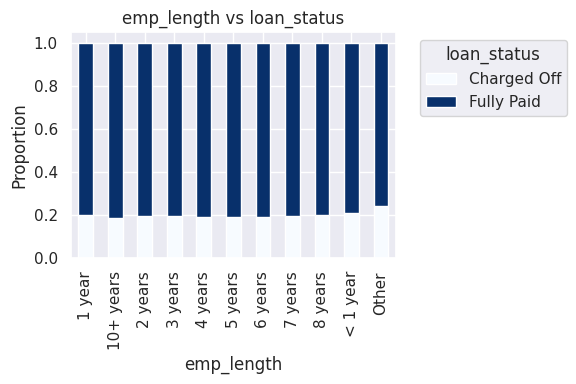


Crosstab: home_ownership vs loan_status


loan_status,Charged Off,Fully Paid
home_ownership,,
ANY,0.000000,1.000000
MORTGAGE,0.169561,0.830439
NONE,0.225806,0.774194
OTHER,0.142857,0.857143
OWN,0.206803,0.793197
RENT,0.226622,0.773378


<Figure size 1000x600 with 0 Axes>

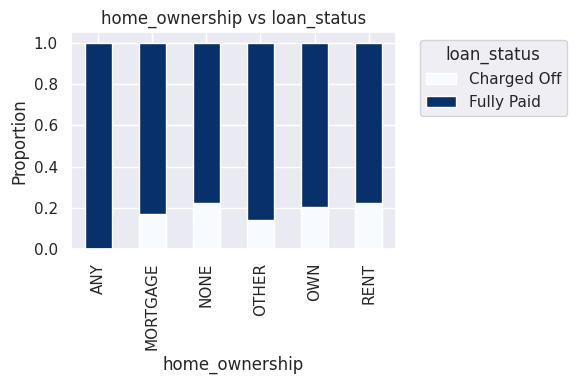


Crosstab: verification_status vs loan_status


loan_status,Charged Off,Fully Paid
verification_status,,
Not Verified,0.146360,0.853640
Source Verified,0.214743,0.785257
Verified,0.223211,0.776789


<Figure size 1000x600 with 0 Axes>

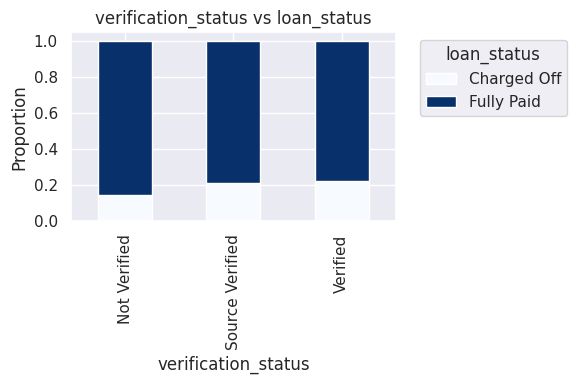


Crosstab: purpose vs loan_status


loan_status,Charged Off,Fully Paid
purpose,,
Other,0.167863,0.832137
car,0.134767,0.865233
credit_card,0.167118,0.832882
debt_consolidation,0.207414,0.792586
home_improvement,0.170079,0.829921
major_purchase,0.164733,0.835267
medical,0.217112,0.782888
moving,0.234758,0.765242
other,0.212178,0.787822


<Figure size 1000x600 with 0 Axes>

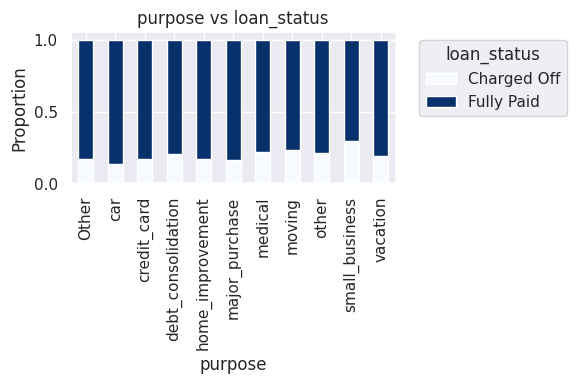


Crosstab: initial_list_status vs loan_status


loan_status,Charged Off,Fully Paid
initial_list_status,,
f,0.193060,0.806940
w,0.200755,0.799245


<Figure size 1000x600 with 0 Axes>

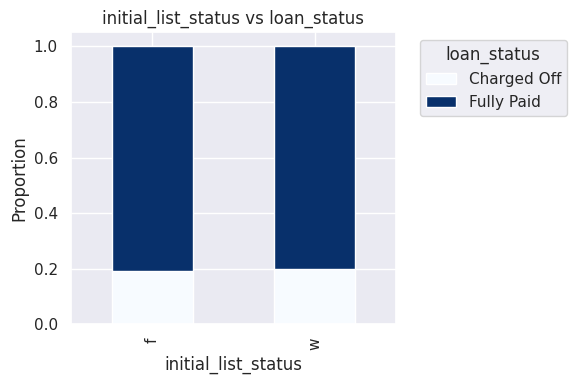


Crosstab: application_type vs loan_status


loan_status,Charged Off,Fully Paid
application_type,,
DIRECT_PAY,0.356643,0.643357
INDIVIDUAL,0.196087,0.803913
JOINT,0.127059,0.872941


<Figure size 1000x600 with 0 Axes>

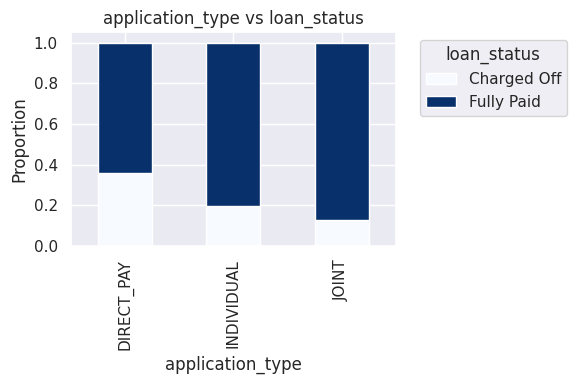


Crosstab: city vs loan_status


loan_status,Charged Off,Fully Paid
city,,
APO,0.199502,0.800498
DPO,0.195675,0.804325
East Michael,0.160772,0.839228
FPO,0.195654,0.804346
Lake Michael,0.182759,0.817241
New Michael,0.188153,0.811847
North Michael,0.200704,0.799296
Other,0.196043,0.803957
Port Michael,0.232787,0.767213


<Figure size 1000x600 with 0 Axes>

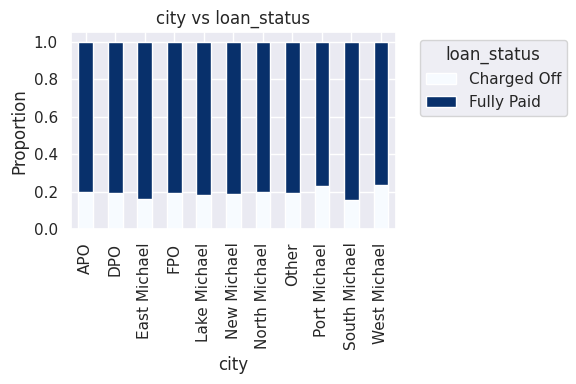


Crosstab: state vs loan_status


loan_status,Charged Off,Fully Paid
state,,
AA,0.194770,0.805230
AE,0.195168,0.804832
AK,0.197612,0.802388
AP,0.200797,0.799203
LA,0.193690,0.806310
MA,0.196098,0.803902
NJ,0.194190,0.805810
NV,0.202472,0.797528
Other,0.195918,0.804082


<Figure size 1000x600 with 0 Axes>

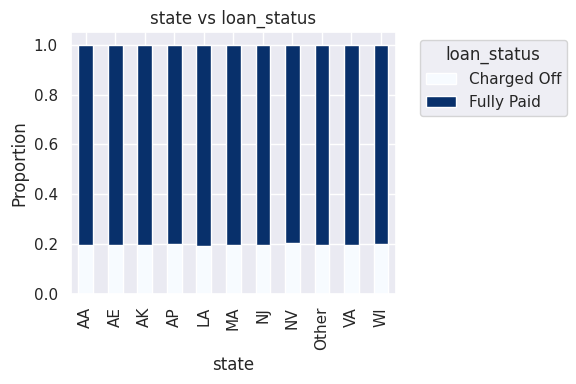

In [ ]:
cats = ['term', 'grade', 'sub_grade', 'emp_length',
        'home_ownership', 'verification_status', 'purpose',
        'initial_list_status', 'application_type', 'city', 'state']

# 1. Generic function: crosstab + plot
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cat_vs_target(df, col, target='loan_status', top_n=None):
    temp = df.copy()
    plt.figure(figsize=(10, 6))
    # optionally keep only top_n categories
    if top_n is not None and temp[col].nunique() > top_n:
        top = temp[col].value_counts().index[:top_n]
        temp[col] = temp[col].where(temp[col].isin(top), other='Other')

    ct = pd.crosstab(temp[col], temp[target], normalize='index')  # default rate per category
    print(f"\nCrosstab: {col} vs {target}")
    display(ct)

    ct.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Blues')

    plt.title(f'{col} vs {target}')
    plt.ylabel('Proportion')
    plt.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

for c in cats:
    plot_cat_vs_target(df, c, 'loan_status', top_n=10)


**Term Vs Loan Status**
- For 36‑month loans, only about 16% are Charged Off and around 84% are Fully Paid, so these are relatively safer.​

- For 60‑month loans, the Charged Off rate roughly doubles to about 32% and Fully Paid drops to ~68%, indicating that longer tenures are significantly riskier and priced accordingly.

**Grade vs loan_status**
- As grade worsens from A → G, the Charged Off rate increases monotonically: roughly 6.3% (A), 12.6% (B), 21.2% (C), 28.9% (D), 37.4% (E), 42.8% (F), and 47.8% (G).​

- This clean gradient confirms that grade is a very strong credit‑risk signal and should be highly predictive in your logistic regression, with lower grades carrying much higher default probability.

**Emp Length Vs Loan Status**

- Most buckets from 1–8 years have Charged Off rates around 18–20% and Fully Paid around 80%, so mid‑range tenures look similar in risk.​

- Borrowers with < 1 year experience have a slightly higher default rate (about 20.7% Charged Off), suggesting marginally higher risk among the least experienced, while 10+ years is a bit safer (about 18.5% Charged Off)


**Home ownership & verification**
- RENT and OWN/NONE have slightly higher Charg*ed Off rates (app 22-23%) than MORTGAGE (~17%), so renters and fully owned homes look a bit riskier than mortgaged borrowers.​

Not Verified borrowers default a bit less (app 14.6%) than Source Verified/Verified (~21–22%), which is counter‑intuitive and may reflect selection effects rather than a true causal pattern.​



**Purpose & application type**
- Loan purpose shows some signal: small_business, moving, and medical have higher default (around 21–29%), while car and major_purchase are safer (~13–17%).​

- DIRECT_PAY applications are clearly riskier (Approximately 35.7% Charged Off) than INDIVIDUAL (~19.6%), while JOINT is safest (Approximately 12.7%), so application_type is a useful predictor.​

**Location features**
- Across city and state, Charged Off rates stay tightly clustered around 19–20%, with only small deviations (e.g., Port/West Michael slightly worse, South Michael slightly better).​

- This suggests geography in this dataset adds limited incremental signal compared to other credit‑risk features and may be lower priority in the model

In [ ]:
from scipy.stats import chi2_contingency

def chi_square_test(df, col, target='loan_status'):
    table = pd.crosstab(df[col], df[target])
    chi2, p, dof, exp = chi2_contingency(table)
    print(f'{col}: chi2={chi2:.2f}, p-value={p:.4f}')

for c in cats:
    chi_square_test(df, c, 'loan_status')

term: chi2=11885.54, p-value=0.0000
grade: chi2=26338.06, p-value=0.0000
sub_grade: chi2=27560.20, p-value=0.0000
emp_length: chi2=122.11, p-value=0.0000
home_ownership: chi2=1860.64, p-value=0.0000
verification_status: chi2=2903.07, p-value=0.0000
purpose: chi2=1397.07, p-value=0.0000
initial_list_status: chi2=35.61, p-value=0.0000
application_type: chi2=59.60, p-value=0.0000
city: chi2=67365.60, p-value=0.6543
state: chi2=48.51, p-value=0.6495


**Strongest predictors (higher chi2)**
 - sub_grade, grade, term have very large chi‑square values, meaning their category distributions differ the most between Charged Off and Fully Paid; these are your most powerful categorical predictors.

- home_ownership, verification_status, purpose, emp_length, application_type also contribute meaningful signal and should be retained in the model.

**Weak / non‑significant predictors**
- city and state have p‑values around 0.65, so you fail to reject the null hypothesis of independence; in other words, default behavior is not meaningfully different across locations here.

- These two can be dropped or heavily regularized, especially since they also tend to be high‑cardinality and may add noise more than predictive power.

In [ ]:
int_columns.columns

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')

In [ ]:
obj_columns.columns

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

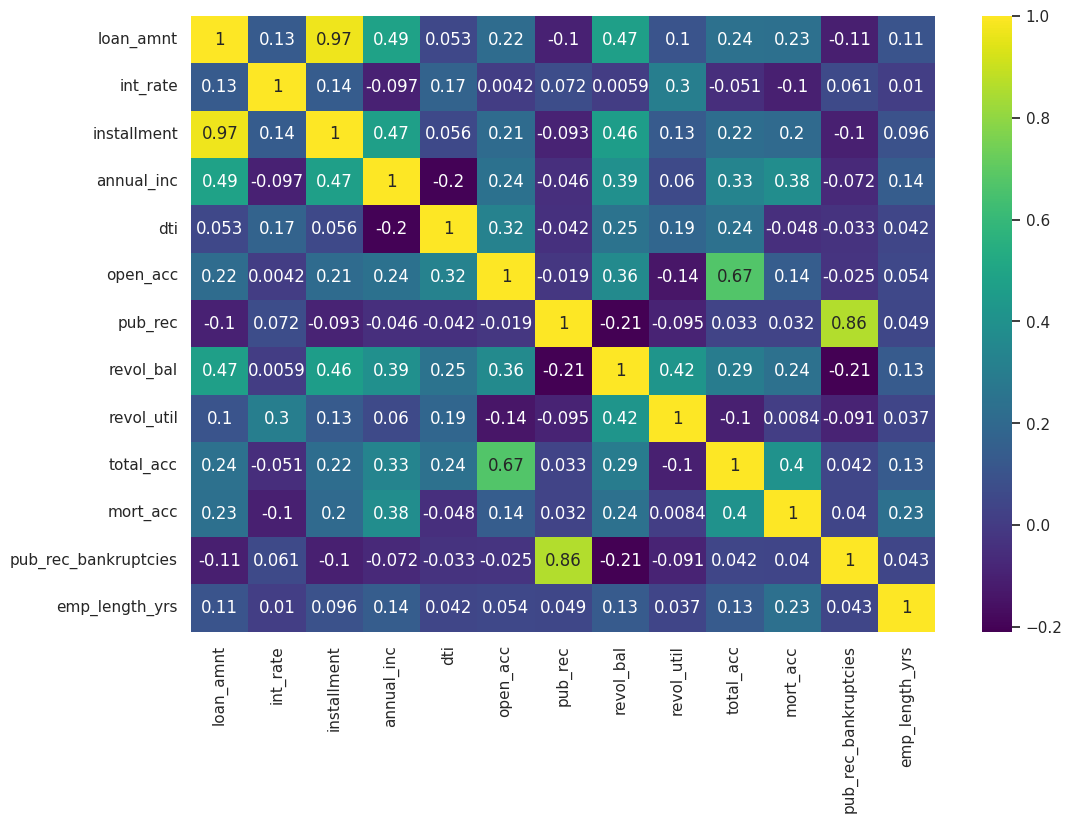

In [ ]:
import warnings
warnings.filterwarnings("ignore")
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(int_columns.corr(method='spearman'),annot=True,cmap='viridis')
plt.show()

- We noticed almost perfect correlation between "loan_amnt" the "installment" feature.

- installment: The monthly payment owed by the borrower if the loan originates.
loan_amnt: The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
- So, we can drop either one of those columns.

**Data Processing**

In [ ]:
duplicates = df.duplicated()

# Display the rows with duplicates
print("Duplicate Rows:")
df[duplicates]

Duplicate Rows:


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,loan_status_num,emp_length_yrs,city,state


- No duplicate values found in the given dataset

In [ ]:
# Display the total number of null values for each column
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,18301
home_ownership,0
annual_inc,0


In [ ]:
df['months'] = df['term'].str.split(' ').str[-2]
df['months'] = pd.to_numeric(df['months'])

In [ ]:
# Dropping the columns from which the requried data is extracted above
columns_to_drop = ['earliest_cr_line', 'address', 'issue_d','term','emp_length','emp_title','title','loan_status']
df = df.drop(columns=columns_to_drop)

**Reason for dropping emp_title and title**

Based on the observation of unique values above, it is apparent that the 'employee title' and 'title' columns do not follow a pattern. The sheer volume of unique values, ranging in the hundreds of thousands suggests a lack of structured categorization. As a result, these columns will be excluded from subsequent analysis due to their limited potential for meaningful insights.

**earliest_cr_line', 'address', 'issue_d','term','emp_length','loan_status'**

Required information from these columns are extracted and created as seperate features ,hence dropping these columns

In [ ]:
df.isna().sum()

,0
loan_amnt,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
purpose,0
dti,0


Missing value treatment using -> Mean/Mode Method

In [ ]:
column_mode = df['emp_length_yrs'].mode()[0]
df['emp_length_yrs'] = df['emp_length_yrs'].fillna(column_mode)

In [ ]:
#Null values replaced by 'Mean' in case of 'Numerical' column.
for column in ['revol_util', 'mort_acc', 'pub_rec_bankruptcies']:
    column_mean = df[column].mean()
    df[column] = df[column].fillna(column_mean)

In [ ]:
# Verify total number of null values for each column is '0'
df.isna().sum()

,0
loan_amnt,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
purpose,0
dti,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype    
---  ------                --------------   -----    
 0   loan_amnt             396030 non-null  float64  
 1   int_rate              396030 non-null  float64  
 2   installment           396030 non-null  float64  
 3   grade                 396030 non-null  object   
 4   sub_grade             396030 non-null  object   
 5   home_ownership        396030 non-null  object   
 6   annual_inc            396030 non-null  float64  
 7   verification_status   396030 non-null  object   
 8   purpose               396030 non-null  object   
 9   dti                   396030 non-null  float64  
 10  open_acc              396030 non-null  float64  
 11  pub_rec               396030 non-null  float64  
 12  revol_bal             396030 non-null  float64  
 13  revol_util            396030 non-null  float64  
 14  total_acc           

In [ ]:
obj_columns.columns

Index(['grade', 'sub_grade', 'home_ownership', 'verification_status',
       'purpose', 'initial_list_status', 'application_type', 'city', 'state'],
      dtype='object')

In [ ]:
#Convert variables from 'Category' datatype to 'String' and 'Integer' datatype
for i in ('grade', 'sub_grade', 'home_ownership', 'verification_status',
       'purpose', 'initial_list_status', 'application_type', 'city', 'state'):
  df[i] = df[i].astype(str)
df['issue_per_month'] = df['issue_per_month'].astype(int)
df['cr_by_month'] = df['issue_per_month'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   int_rate              396030 non-null  float64
 2   installment           396030 non-null  float64
 3   grade                 396030 non-null  object 
 4   sub_grade             396030 non-null  object 
 5   home_ownership        396030 non-null  object 
 6   annual_inc            396030 non-null  float64
 7   verification_status   396030 non-null  object 
 8   purpose               396030 non-null  object 
 9   dti                   396030 non-null  float64
 10  open_acc              396030 non-null  float64
 11  pub_rec               396030 non-null  float64
 12  revol_bal             396030 non-null  float64
 13  revol_util            396030 non-null  float64
 14  total_acc             396030 non-null  float64
 15  

In [ ]:
# Encode the 'Categorical' variable using Label Encoder
from sklearn.preprocessing import LabelEncoder

# Separate features and target variable
X = df.drop(columns= ['loan_status_num'])
y = df['loan_status_num']

# Initialize LabelEncoder
label_encoder = LabelEncoder()

for i in ('grade', 'sub_grade', 'home_ownership', 'verification_status',
       'purpose', 'initial_list_status', 'application_type', 'city', 'state'):

  # Fit and transform the categorical column
  X[i] = label_encoder.fit_transform(X[i])

- Categorical columns need to be converted to Numerical columns for the model to be trained since Logistic Regression works on numerical values of the variables.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   int_rate              396030 non-null  float64
 2   installment           396030 non-null  float64
 3   grade                 396030 non-null  int64  
 4   sub_grade             396030 non-null  int64  
 5   home_ownership        396030 non-null  int64  
 6   annual_inc            396030 non-null  float64
 7   verification_status   396030 non-null  int64  
 8   purpose               396030 non-null  int64  
 9   dti                   396030 non-null  float64
 10  open_acc              396030 non-null  float64
 11  pub_rec               396030 non-null  float64
 12  revol_bal             396030 non-null  float64
 13  revol_util            396030 non-null  float64
 14  total_acc             396030 non-null  float64
 15  

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state = 43)

In [ ]:
print(f'Traning Data:\n{y_train.value_counts()}\n\nValidation Data:\n{y_val.value_counts()}\n\nTesting Data:\n{y_test.value_counts()}')

Traning Data:
loan_status_num
1    222918
0     54303
Name: count, dtype: int64

Validation Data:
loan_status_num
1    47621
0    11783
Name: count, dtype: int64

Testing Data:
loan_status_num
1    47818
0    11587
Name: count, dtype: int64


- It can be observed from the above value counts that the data is imbalanced for outcomes '1' and '0'.
- SMOTE technique is one of the techniques that can be used to balance the data by oversampling the records. SMOTE uses the nearest neighbour concept to oversample data.
- The oversampling will be done for training data only since the model should be making predictions on the real world data, the imbalance in validation and testing data will remain as is

In [ ]:
# Balance data using SMOTE technique
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
# Verify training data is balanced
print(f'Traning Data:\n{y_train_smote.value_counts()}')

Traning Data:
loan_status_num
1    222918
0    222918
Name: count, dtype: int64


In [ ]:
# Check the collinearity among variables
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_smote.columns
vif_data["VIF"] = [round(variance_inflation_factor(X_train_smote.values, i), 4) for i in range(X_train_smote.shape[1])]

# Display the VIF values
print(vif_data)

                Variable          VIF
0              loan_amnt     251.9807
1               int_rate     280.3501
2            installment     223.4137
3                  grade      44.1025
4              sub_grade     169.0497
5         home_ownership       4.7789
6             annual_inc       3.4722
7    verification_status       2.9624
8                purpose       2.6468
9                    dti       2.2726
10              open_acc      13.7274
11               pub_rec       1.8483
12             revol_bal       2.1979
13            revol_util       8.6646
14             total_acc      14.4159
15   initial_list_status       1.7630
16      application_type     476.7191
17              mort_acc       2.8319
18  pub_rec_bankruptcies       1.9300
19        emp_length_yrs       4.6048
20                  city       3.2559
21                 state       3.8600
22       issue_per_month          inf
23            issue_year  112293.0434
24            cr_by_year  108018.9781
25          

In [ ]:
high_vif_cols = vif_data.loc[vif_data['VIF'] >= 10, 'Variable'].tolist()

print("Columns to drop:", high_vif_cols)



Columns to drop: ['loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade', 'open_acc', 'total_acc', 'application_type', 'issue_per_month', 'issue_year', 'cr_by_year', 'cr_by_month', 'months']


- Removing columns with high VIF (i.e. VIF>10) to eliminate collinearity between variables.

- After removing the collinear columns the VIF for remaining columns is within the limit which indicates tolerable collinearity among the remaining variables.

- Standardizing the data improves the performance and interpretability of the model, and ensures that the algorithm is not influenced by the scale of the input variables

In [ ]:
# Standardize the data
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the dataset
X_trainu = scaler.fit_transform(X_train_smote)
X_valu = scaler.fit_transform(X_val)
X_testu = scaler.fit_transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Logistic Regression model
model = LogisticRegression(penalty='l2', solver='liblinear')

# Train the model on the training set
model.fit(X_trainu, y_train_smote)

LogisticRegression(solver='liblinear')

In [ ]:
print(f'Weights:\abs({model.coef_[0]}')
print(X.info())

Weights:
[-0.04878445 -0.63468397 -0.07399863  2.16624516 -2.05080552 -0.00855471
  0.12430151  0.28586794  0.04596673 -0.49096828 -0.09713899 -0.10304682
  0.0616398  -0.05958316  0.12408464  0.39195046  0.04613368  0.12415732
  0.02686788  0.00680342 -0.00542932  0.02077853 -1.33350799  2.51207526
  0.07473333 -1.33350799 -0.27500603]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   int_rate              396030 non-null  float64
 2   installment           396030 non-null  float64
 3   grade                 396030 non-null  int64  
 4   sub_grade             396030 non-null  int64  
 5   home_ownership        396030 non-null  int64  
 6   annual_inc            396030 non-null  float64
 7   verification_status   396030 non-null  int64  
 8   purpose               396

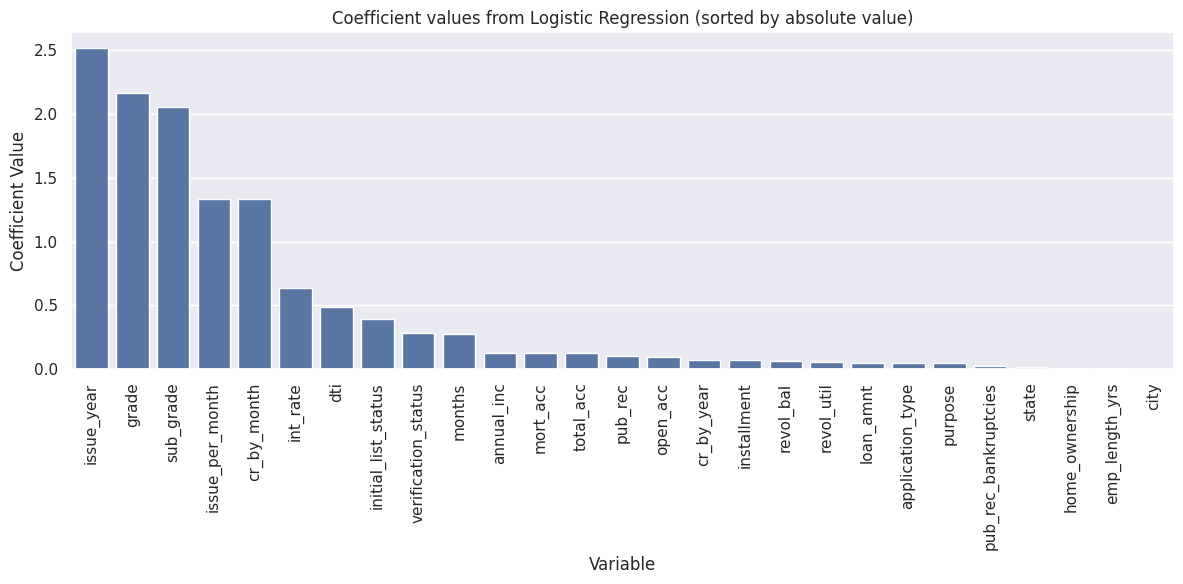

In [ ]:
coefficients = model.coef_[0]

# Create a pandas Series with coefficients and feature names
coefficients_series = pd.Series(coefficients, index=X.columns)

# Sort coefficients by absolute value in descending order
sorted_indices = coefficients_series.abs().sort_values(ascending=False).index
coefficients_sorted = coefficients_series.loc[sorted_indices].abs()

# Plot
plt.figure(figsize=(12, 6)) # Adjusted figure size for better readability
sns.barplot(x=coefficients_sorted.index, y=coefficients_sorted.values)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.title('Coefficient values from Logistic Regression (sorted by absolute value)')
plt.ylabel('Coefficient Value')
plt.xlabel('Variable')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

- Issue year and Grades have the heighest weight i.e, they contribute more to the chance of loan payment

> Add blockquote



Accuracy: 0.5589859268736111

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.68      0.38     11783
           1       0.87      0.53      0.66     47621

    accuracy                           0.56     59404
   macro avg       0.57      0.60      0.52     59404
weighted avg       0.75      0.56      0.60     59404


Confusion Matrix:


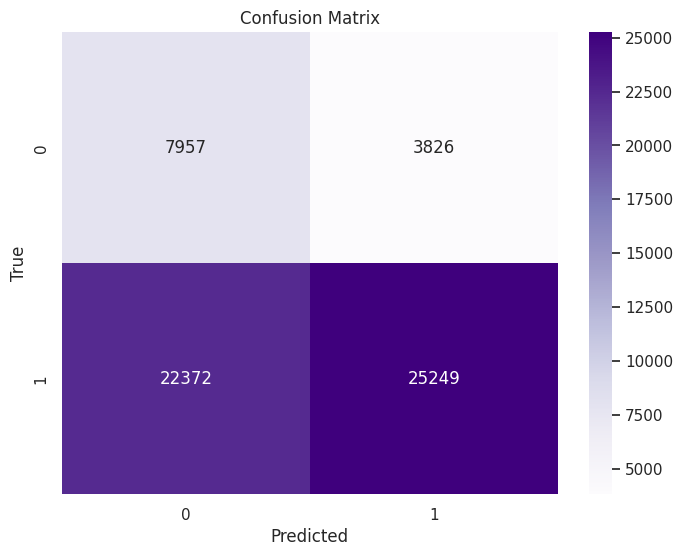

In [ ]:
# Predictions on the validation set
yval_pred = model.predict(X_valu)

# Evaluate the model
accuracy = accuracy_score(y_val, yval_pred)
conf_matrix = confusion_matrix(y_val, yval_pred)
classification_rep = classification_report(y_val, yval_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_rep)

print("\nConfusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Insights**
Accuracy: 0.5589 (~56%):

The overall accuracy of the model is approximately 56%, indicating the proportion of correctly classified instances among the total instances.

**Precision:**

Precision is the ratio of true positive predictions to the total predicted positives.
Precision for class 0 (precision_0): 0.26 (26%)
Precision for class 1 (precision_1): 0.87 (87%)
Precision is high for class 1, indicating that when the model predicts class 1, it is correct about 87% of the time. However, precision is lower for class 0, suggesting that when the model predicts class 0, it is correct about 26% of the time.

**Recall:**

Recall, also known as sensitivity or true positive rate, is the ratio of true positive predictions to the total actual positives.
Recall for class 0 (recall_0): 0.68 (68%)
Recall for class 1 (recall_1): 0.53 (53%)
The model has a higher recall for class 0, indicating that it effectively identifies about 68% of the actual instances of class 0. However, the recall is lower for class 1, suggesting that it identifies about 53% of the actual instances of class 1

**F1-Score:**

F1-score is the harmonic mean of precision and recall, providing a balance between the two metrics.
F1-score for class 0 (f1-score_0): 0.38
F1-score for class 1 (f1-score_1): 0.66
The F1-scores reflect a trade-off between precision and recall. Class 1 has a higher F1-score, indicating a better balance between precision and recall for class 1 compared to class 0.

**Support:**

Support represents the number of actual occurrences of each class in the specified dataset.
Support for class 0: 11783 instances
Support for class 1: 47621 instances

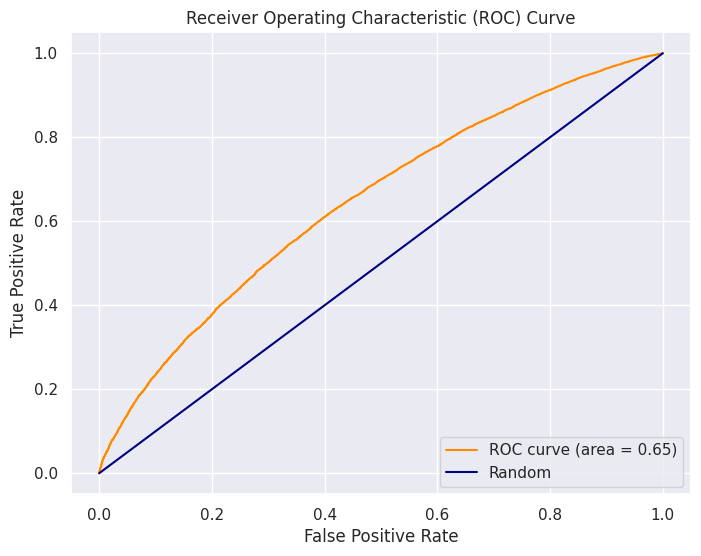

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_prob = model.predict_proba(X_valu)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

nsights¶
An AU-ROC value of 0.65 suggests that, on average, the model has a good ability to distinguish between the positive and negative classes, but there is room for improvement.

Accuracy: 0.5564851443481188

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.67      0.37     11587
           1       0.87      0.53      0.66     47818

    accuracy                           0.56     59405
   macro avg       0.56      0.60      0.51     59405
weighted avg       0.75      0.56      0.60     59405


Confusion Matrix:


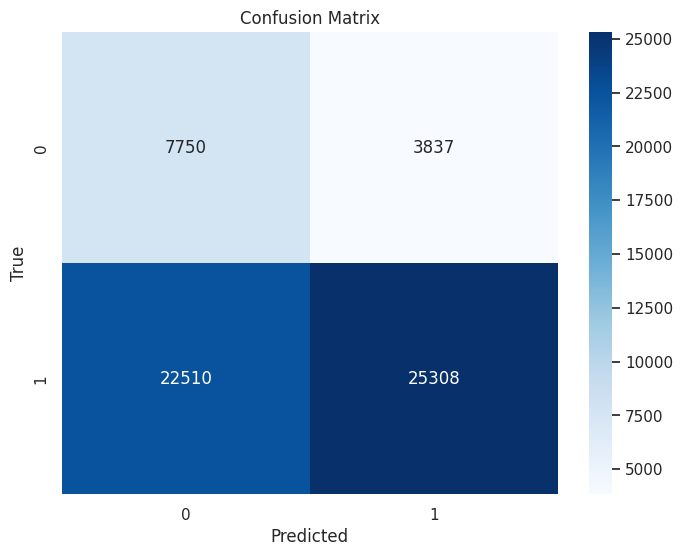

In [ ]:
y_pred = model.predict(X_testu)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_rep)

print("\nConfusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Insights Accuracy: 0.5564(~56%):

The overall accuracy of the model is approximately 56%, indicating the proportion of correctly classified instances among the total instances.

Precision:

Precision is the ratio of true positive predictions to the total predicted positives. Precision for class 0 (precision_0): 0.26 (26%) Precision for class 1 (precision_1): 0.87 (87%) Precision is high for class 1, indicating that when the model predicts class 1, it is correct about 87% of the time. However, precision is lower for class 0, suggesting that when the model predicts class 0, it is correct about 26% of the time.

Recall:

Recall, also known as sensitivity or true positive rate, is the ratio of true positive predictions to the total actual positives. Recall for class 0 (recall_0): 0.67 (67%) Recall for class 1 (recall_1): 0.53 (53%) The model has a higher recall for class 0, indicating that it effectively identifies about 68% of the actual instances of class 0. However, the recall is lower for class 1, suggesting that it identifies about 53% of the actual instances of class 1

F1-Score:

F1-score is the harmonic mean of precision and recall, providing a balance between the two metrics. F1-score for class 0 (f1-score_0): 0.37 F1-score for class 1 (f1-score_1): 0.66 The F1-scores reflect a trade-off between precision and recall. Class 1 has a higher F1-score, indicating a better balance between precision and recall for class 1 compared to class 0.

Support:

Support represents the number of actual occurrences of each class in the specified dataset. Support for class 0: 11587 instances Support for class 1: 47818 instances

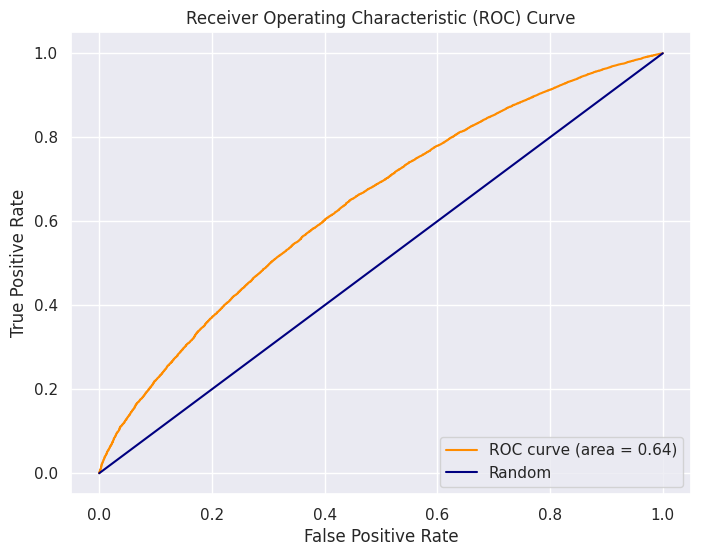

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_prob = model.predict_proba(X_testu)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

- An AU-ROC value of 0.64 suggests that, on average, the model has a good ability to distinguish between the positive and negative classes, but there is room for improvement.

**Insights**
- The low precision value for class 0 can be due to the imbalance of data for the same, if more real time data for class 0 can be provided, the model can be trained better and the performance might increase.

- Also since the data consists of a lot of categorical columns a different ML model might prove better in predicting the outcome than Logistic Regression.
The model's precision value of 0.87 signifies that it accurately predicts the likelihood of loan repayment in 87% of cases.
The model's precision value of 0.38 for charged-off loans indicates that, among the instances predicted as charged off, only 26% were correctly classified, emphasizing a lower accuracy in predicting this specific class.

- The model's sensitivity value of 0.65 for loan repayment signifies that it accurately identifies 65% of the instances where loans are repaid, demonstrating its ability to effectively capture a significant portion of the actual loan repayment cases.

- The model's sensitivity value of 0.65 for charged-off loans signifies that it correctly identifies 65% of the actual charged-off instances, reflecting its ability to capture a substantial portion of the relevant cases for this class.
- The features that heavily affected the models outcome are
grade - LoanTap assigned loan grade (Risk ratings by LoanTap)
pub_rec - Negative records on borrower's public credit profile.
- “Loan issuance volume increased sharply from 2011 and peaked in 2013–2014, indicating a period of rapid portfolio growth.”

- “Post‑2014, the annual number of loans declined, so later years have fewer observations, which the model should account for when interpreting time‑based patterns.”

Recommendation

- Provide more options for the term period so customers can make payments according to their incomes.
- Give an equal number of loans to high-paying job title customers; expectations for full payment can be higher.
- Approve loans for EDUCATION, MEDICAL & other important purposes with Strict Approval Criteria to create loyalty with customers with the bank.